### Gini

Gini Index:
$$Gini(S) = 1 - \sum_{i=1}^{c} (p_i)^2$$

General Gini:
$$Gini_{split} = \frac{|S_{left}|}{|S|} Gini(S_{left}) + \frac{|S_{right}|}{|S|} Gini(S_{right})$$

$Gini = 1 - ((6/8)^2 + (2/8)^2) = 0.375$

$Gini = 1 - ((3/6)^2 + (3/6)^2) = 0.5$

$$Gini_{Wind} = \frac{8}{14} \cdot 0.375 + \frac{6}{14} \cdot 0.5 \approx \mathbf{0.428}$$

$$Gini_{Outlook} = \left( \frac{5}{14} \cdot 0.48 \right) + \left( \frac{4}{14} \cdot 0 \right) + \left( \frac{5}{14} \cdot 0.48 \right)\approx \mathbf{0.3428}$$


<font color = green >

# Decision Trees
</font>

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
%matplotlib inline 

<font color = green >

## Iris dataset 
</font>

In [3]:
# Don't install graphviz with the help of pip, use conda install  graphviz
# !pip install graphviz

In [4]:
# !conda install graphviz

In [5]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import graphviz
from sklearn.model_selection import train_test_split
# Note: In case of RuntimeError "Make sure the Graphviz executables are on your system's path” after installing Graphviz 
# helps on mac:  brew install graphviz
# helps on windows:  import os
# os.environ["PATH"] += os.pathsep + r'C:\Program Files (x86)\Graphviz2.38\bin'

In [6]:
iris= load_iris()

iris = load_iris()
X, y, features, labels = iris.data, iris.target,iris.feature_names ,iris.target_names

print ('X.shape= ', X.shape)
print ('y.shape= ', y.shape)
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 3)
print ('X_train.shape= ',X_train.shape)
print ('X_test.shape= ',X_test.shape)
print ('y_train.shape= ',y_train.shape)
print ('y_test.shape= ',y_test.shape)
print ('features:', features)
dict_names = {i:v for i,v in enumerate(labels)}
print ('target names :', dict_names)

X.shape=  (150, 4)
y.shape=  (150,)
X_train.shape=  (112, 4)
X_test.shape=  (38, 4)
y_train.shape=  (112,)
y_test.shape=  (38,)
features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
target names : {0: np.str_('setosa'), 1: np.str_('versicolor'), 2: np.str_('virginica')}


<font color = green >

## Learning the model
</font>

In [7]:
max_depth = 3
clf = DecisionTreeClassifier(
    criterion=  'entropy',
    random_state=20,        
    max_depth=max_depth,    
#     max_leaf_nodes=4,
).fit(X_train, y_train)
print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 98.214%
test accuracy= 97.368%


In [8]:
max_depth = 2
clf = DecisionTreeClassifier(
    criterion=  'gini',
    random_state=20,        
#     max_leaf_nodes=4,
).fit(X_train, y_train)
print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 94.737%


<font color = green >

## Vizualize the decision tree  graph 
</font>

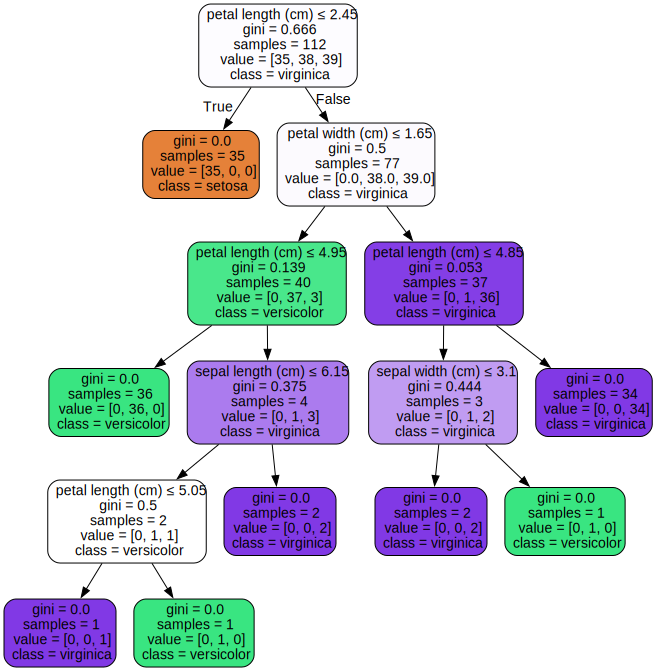

In [9]:
dot_data = tree.export_graphviz(clf, out_file=None, 
                                feature_names=features,  
                                class_names=labels,  
                                filled=True, 
                                rounded=True,  
                                special_characters=True)  

graph = graphviz.Source(dot_data)  

display(graph)

<font color = green >

## Feature importance
</font>

In [10]:
def plot_feature_importances(clf, features):
    plt.figure(figsize=(6, 6), dpi=80)
    c_features = len(features)
    plt.barh(range(c_features), clf.feature_importances_)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature name")
    plt.yticks(np.arange(c_features), features)

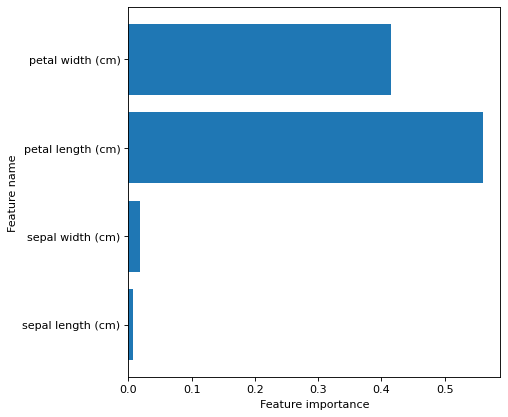

In [11]:
plot_feature_importances(clf, features)

<font color = green >

## Regressor
</font>

In [12]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

In [13]:
X, y = make_regression(n_samples=500, n_features=5, noise=0.2, random_state=42)
features = ['Size', 'Year', 'Rooms', 'Location', 'Condition']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [14]:
reg_tree = DecisionTreeRegressor(max_depth=3, random_state=10).fit(X_train, y_train)

In [15]:
print(f"Train R² Score: {reg_tree.score(X_train, y_train):.3%}")
print(f"Test R² Score:  {reg_tree.score(X_test, y_test):.3%}")

Train R² Score: 71.579%
Test R² Score:  69.929%


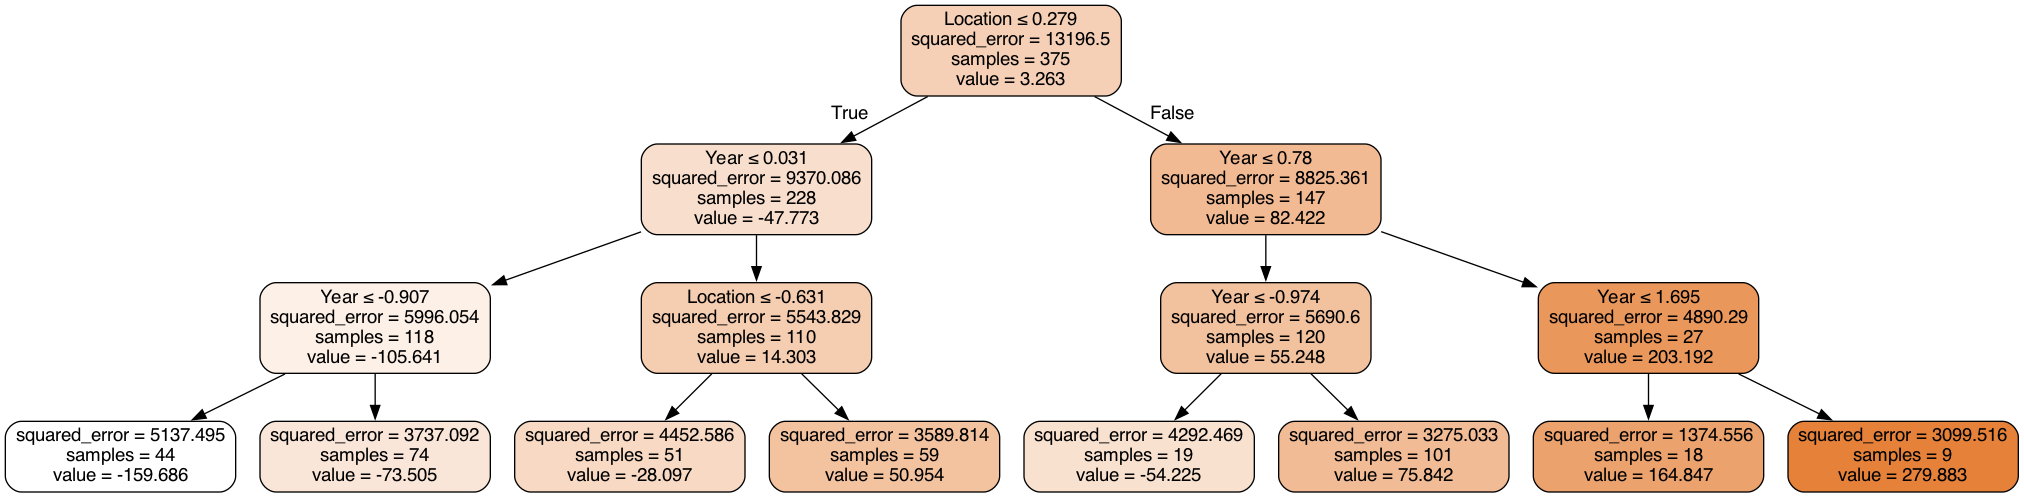

In [16]:
from IPython.display import Image

dot_data = tree.export_graphviz(reg_tree, out_file=None, 
                                feature_names=features,  
                                filled=True, 
                                rounded=True,  
                                special_characters=True)  

graph = graphviz.Source(dot_data)  

Image(graph.pipe(format='png'), width=1900, height=1000)

In [17]:
def plot_feature_importances(clf, features):
    plt.figure(figsize=(8, 5), dpi=80)
    n_features = len(features)
    plt.barh(range(n_features), clf.feature_importances_, color='lightgreen', edgecolor='black')
    plt.xlabel("Feature Importance (Contribution to Variance Reduction)")
    plt.ylabel("Feature Name")
    plt.yticks(np.arange(n_features), features)
    plt.title("Decision Tree Regression: Feature Importances")
    plt.show()

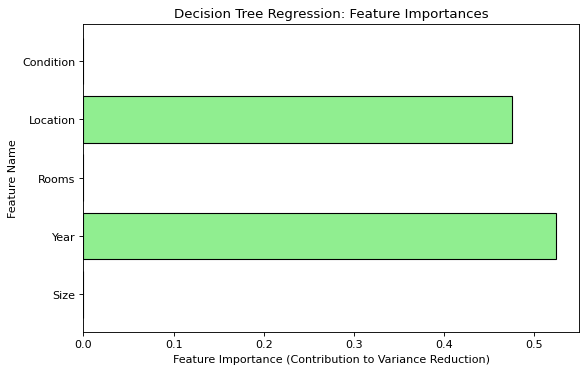

In [18]:
plot_feature_importances(reg_tree, features)

<font color = green >

## Auxiliary drawing functions 
</font>

In [19]:
def plot_decision_boundary(clf, X_train, y_train, X_test=None, y_test= None, title=None, precision=0.05,plot_symbol_size = 50, ax= None,  is_extended=True, title_size= None):

    '''    
    Draws the binary decision boundary for X that is nor required additional features and transformation (like polynomial)
    '''
    # Create color maps - required by pcolormesh
    from matplotlib.colors import  ListedColormap
    colors_for_points = np.array(['grey', 'orange']) # neg/pos
    colors_for_areas = np.array(['grey', 'orange']) # neg/pos  # alpha is applied later 
    cmap_light = ListedColormap(colors_for_areas)
 
   
    mesh_step_size = precision #.01  # step size in the mesh
    if X_test is None or y_test is None:
        show_test= False
        X= X_train
    else:
        show_test= True
        X= np.concatenate([X_train,X_test], axis=0)
    x1_min, x1_max = X[:, 0].min() - .1, X[:, 0].max() + 0.1
    x2_min, x2_max = X[:, 1].min() - .1, X[:, 1].max() + 0.1
    # Create grids of pairs
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, mesh_step_size),
                         np.arange(x2_min, x2_max, mesh_step_size))
    # Flatten all samples 
    target_samples_grid= (np.c_[xx1.ravel(), xx2.ravel()])

    print ('Call prediction for all grid values (precision of drawing = {},\n you may configure to speed up e.g. precision=0.05)'.format(precision))
    Z = clf.predict(target_samples_grid)

    # Reshape the result to original meshgrid shape 
    Z = Z.reshape(xx1.shape)
    
    if ax:
        plt.sca(ax)
    
    # Plot all meshgrid prediction      
    plt.pcolormesh(xx1, xx2,Z, cmap = cmap_light, alpha=0.2)

    # Plot train set
    plt.scatter(X_train[:, 0], X_train[:, 1], s=plot_symbol_size, 
                c=colors_for_points[y_train.ravel()], edgecolor = 'black',alpha=0.6)
    # Plot test set
    if show_test:
        plt.scatter(X_test[:, 0], X_test[:, 1], marker='^', s=plot_symbol_size, 
                c=colors_for_points[y_test.ravel()],edgecolor = 'black',alpha=0.6)
    if  is_extended:
        # Create legend  
        import matplotlib.patches as mpatches # use to assign lavels for colored points 
        patch0 = mpatches.Patch(color=colors_for_points[0], label='negative')
        patch1 = mpatches.Patch(color=colors_for_points[1], label='positive')
        plt.legend(handles=[patch0, patch1])
    
    fontdict={'fontsize': title_size} if title_size else None
    
    plt.title(title, fontdict)
    if is_extended:
        plt.xlabel('feature 1')
        plt.ylabel('feature 2')
    else:
        plt.tick_params(
        top =False,
        bottom= False,
        left  = False,
        labelleft = False, 
        labelbottom = False
        )

        
    
def plot_data_logistic_regression(X,y,legend_loc= None, title= None):
    '''
    :param X: 2 dimensional ndarray
    :param y:  1 dimensional ndarray. Use y.ravel() if necessary
    :return:
    '''

    positive_indices = (y == 1)
    negative_indices = (y == 0)
#     import matplotlib as mpl
    colors_for_points = ['grey', 'orange'] # neg/pos

    plt.scatter(X[negative_indices][:,0], X[negative_indices][:,1], s=40, c=colors_for_points [0], edgecolor = 'black', label='negative', alpha = 0.7)
    plt.scatter(X[positive_indices][:,0], X[positive_indices][:,1], s=40, c=colors_for_points [1], edgecolor = 'black',label='positive', alpha = 0.7)
    plt.title(title)
    plt.legend(loc= legend_loc)

    
def plot_multi_class_logistic_regression(X,y,dict_names=None, colors= None,  title =None):
    '''
    Draw the multi class samples of 2 features
    :param X: X 2 ndarray (m,2),
    :param y: vector (m,)
    :param dict_names: dict of values of y and names
    :return: None
    '''
    if not colors:
        colors_for_points = ['green','grey', 'orange', 'brown']
    else:
         colors_for_points = colors

    y_unique = list(set(y))

    for i in range (len(y_unique)):
        ind = y == y_unique[i] # vector

        if dict_names:
            plt.scatter(X[ind,0], X[ind,1], c=colors_for_points[i], s=40, label=dict_names[y_unique[i]],edgecolor='black', alpha=.7)
        else:
            plt.scatter(X[ind, 0], X[ind, 1], s=40, c=colors_for_points [i], edgecolor = 'black', alpha = 0.7)
    if title:
        plt.title(title)

    if dict_names:
        plt.legend(frameon=True)
        


<font color = green >

## Synthetic dataset
</font>

In [20]:
from sklearn.datasets import make_blobs

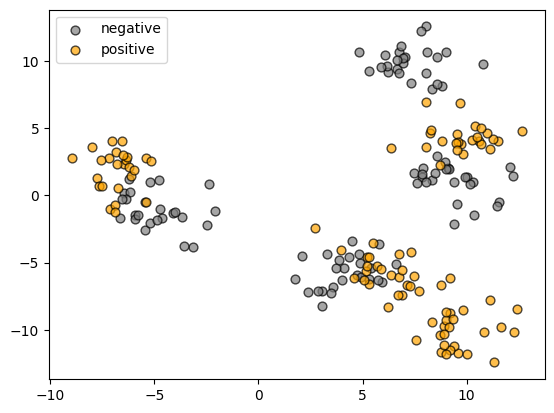

In [21]:
X_mk8, y_mk8 = make_blobs(n_samples = 200, n_features = 2, centers = 8, # centers impacts for y
                       cluster_std = 1.3, random_state = 4)
X_train = X_mk8
y_train = y_mk8 % 2 # make it binary since make_blobs  with centers = 8 creates y in [0..7]
plt.figure()
plot_data_logistic_regression(X_mk8,y_train)


Call prediction for all grid values (precision of drawing = 0.05,
 you may configure to speed up e.g. precision=0.05)
Call prediction for all grid values (precision of drawing = 0.05,
 you may configure to speed up e.g. precision=0.05)
Call prediction for all grid values (precision of drawing = 0.05,
 you may configure to speed up e.g. precision=0.05)


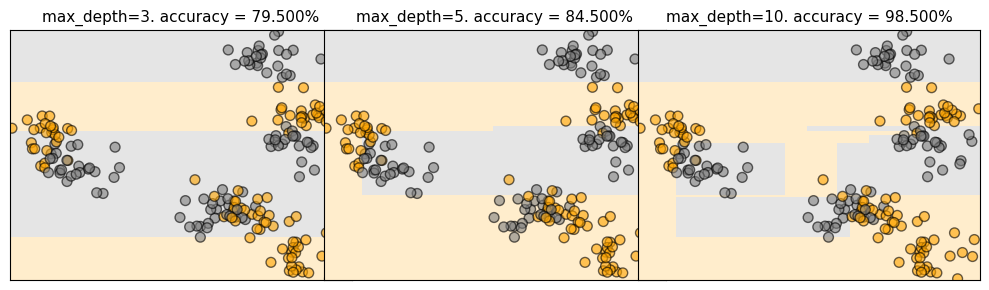

In [22]:
plt.figure(figsize= (10,3))
max_depths= [3,5,10]    

for i, max_depth in enumerate(max_depths):
    ax = plt.subplot(1,len(max_depths),i+1)
    clf = DecisionTreeClassifier(
        criterion=  'entropy',
        random_state=20,        
        max_depth=max_depth,    
    #     max_leaf_nodes=4,
    ).fit(X_train, y_train)
    accuracy = clf.score (X_train, y_train)
#     print("train accuracy= {:.3%}".format(accuracy))
    plot_decision_boundary(
        clf,
        X_train,
        y_train,
        precision= 0.05,
        ax=ax,
        title = 'max_depth={}. accuracy = {:.3%}'.format(max_depth, accuracy),
        is_extended= False,
        title_size= 11,)
    
plt.tight_layout (w_pad=-2)


# max_depth=5    
# clf = DecisionTreeClassifier(
#     criterion=  'entropy',
#     random_state=20,        
#     max_depth=max_depth,    
# #     max_leaf_nodes=4,
# ).fit(X_train, y_train)
# accuracy = clf.score (X_train, y_train)
# print("train accuracy= {:.3%}".format(accuracy))
# plt.figure()

# plot_decision_boundary(clf, X_train, y_train, precision= 0.05, title = 'max_depth={}. accuracy = {:.3%}'.format(max_depth, accuracy))

In [23]:
# graph_viz = tree.export_graphviz(clf, out_file=None,filled = True)
# graph = graphviz.Source(graph_viz)
# graph.view(cleanup =True) # cleanup (bool) – Delete the source file after rendering.

#### Should appear the followingf image in separate window 

<img src = "data/decision_tree_graph2.jpg" height=500 width= 500 align="left">

<div style="clear:left;"></div>
<br><br><br><br><br><br><br><br>


<font color = green >

## Tennis dataset

</font>

In [24]:
import os
import pandas as pd
cwd= os.getcwd() # current working directory
# path = os.path.join(cwd,'data')
# fn=  os.path.join(path , 'tennis.csv')
fn=  'data/tennis.csv'
df = pd.read_csv(fn)
del df['temp']
print (df.head())

X_train = df.iloc[:, :3].values
y_train = df.iloc[:, 3].values
print ('\nX_train.shape= ',X_train.shape)
print ('y_train.shape= ',y_train.shape)

    outlook humidity   wind play
0     sunny     high  False   no
1     sunny     high   True   no
2  overcast     high  False  yes
3     rainy     high  False  yes
4     rainy   normal  False  yes

X_train.shape=  (14, 3)
y_train.shape=  (14,)


In [25]:
from sklearn.preprocessing  import LabelEncoder

In [26]:
X_train_cat = X_train.copy()
le = LabelEncoder()
for i in range(X_train.shape[1]):
    X_train_cat[:,i]= le.fit_transform(X_train[:,i])
    le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
    print ('{}: {}'.format(list(df)[i], le_dict))
y_train_cat= le.fit_transform(y_train)
le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
print ('y: ', le_dict)
print ('X_train_cat.shape= ',X_train_cat.shape)
print ('y_train_cat.shape= ',y_train_cat.shape)
X_train_cat

outlook: {'overcast': np.int64(0), 'rainy': np.int64(1), 'sunny': np.int64(2)}
humidity: {'high': np.int64(0), 'normal': np.int64(1)}
wind: {False: np.int64(0), True: np.int64(1)}
y:  {'no': np.int64(0), 'yes': np.int64(1)}
X_train_cat.shape=  (14, 3)
y_train_cat.shape=  (14,)


array([[2, 0, 0],
       [2, 0, 1],
       [0, 0, 0],
       [1, 0, 0],
       [1, 1, 0],
       [1, 1, 1],
       [0, 1, 1],
       [2, 0, 0],
       [2, 1, 0],
       [1, 1, 0],
       [2, 1, 1],
       [0, 0, 1],
       [0, 1, 0],
       [1, 0, 1]], dtype=object)

In [27]:
max_depth = None
clf = DecisionTreeClassifier(
    criterion=  'entropy',
    random_state=20,        
    max_depth=max_depth,    
    # max_leaf_nodes=4,
).fit(X_train_cat, y_train_cat)
features = list(df)[:3]
labels = ['No','Yes']

print("train accuracy= {:.3%}".format(clf.score (X_train_cat, y_train_cat)))

train accuracy= 100.000%


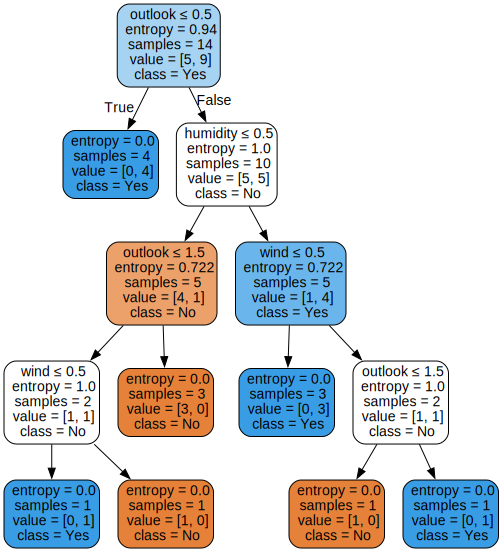

In [28]:
dot_data = tree.export_graphviz(clf, out_file=None, 
                                feature_names=list(features),  
                                class_names=[str(l) for l in labels],  
                                filled=True, 
                                rounded=True,  
                                special_characters=True)  

graph = graphviz.Source(dot_data)  

display(graph)

<font color = green>

#  Random Forests

</font>



In [29]:
from sklearn.ensemble import RandomForestClassifier

<font color = green>

## Iris dataset

</font>



In [30]:
iris = load_iris()
X, y, features, labels = iris.data, iris.target,iris.feature_names ,iris.target_names

print ('X.shape= ', X.shape)
print ('y.shape= ', y.shape)
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 3)
print ('X_train.shape= ',X_train.shape)
print ('X_test.shape= ',X_test.shape)
print ('y_train.shape= ',y_train.shape)
print ('y_test.shape= ',y_test.shape)
print ('features:', features)
dict_names = {i:v for i,v in enumerate(labels)}
print ('target names :', dict_names)

X.shape=  (150, 4)
y.shape=  (150,)
X_train.shape=  (112, 4)
X_test.shape=  (38, 4)
y_train.shape=  (112,)
y_test.shape=  (38,)
features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
target names : {0: np.str_('setosa'), 1: np.str_('versicolor'), 2: np.str_('virginica')}


In [31]:
clf = RandomForestClassifier().fit (X_train, y_train)
clf.score (X_train, y_train)
n_estimators_list= [5,10,20]
max_features_list= list(np.arange(1, X_train.shape[1]+1))

for i in range (len(n_estimators_list)): 
    for j in range (len(max_features_list)):
        index = len(max_features_list)*i+j           
        clf = RandomForestClassifier(
            random_state=10,
            n_estimators= n_estimators_list[i],
            max_features=max_features_list[j],        
        ).fit(X_train, y_train)
        accuracy_train = clf.score (X_train, y_train)
        accuracy_test = clf.score (X_test, y_test)
        print ('n_estimators= {}, max_features = {}, accuracy_train = {:.3%}, accuracy_test = {:.3%}'.format (
            n_estimators_list[i],max_features_list[j], accuracy_train, accuracy_test))

n_estimators= 5, max_features = 1, accuracy_train = 98.214%, accuracy_test = 94.737%
n_estimators= 5, max_features = 2, accuracy_train = 98.214%, accuracy_test = 94.737%
n_estimators= 5, max_features = 3, accuracy_train = 98.214%, accuracy_test = 94.737%
n_estimators= 5, max_features = 4, accuracy_train = 98.214%, accuracy_test = 94.737%
n_estimators= 10, max_features = 1, accuracy_train = 100.000%, accuracy_test = 94.737%
n_estimators= 10, max_features = 2, accuracy_train = 100.000%, accuracy_test = 97.368%
n_estimators= 10, max_features = 3, accuracy_train = 100.000%, accuracy_test = 94.737%
n_estimators= 10, max_features = 4, accuracy_train = 100.000%, accuracy_test = 94.737%
n_estimators= 20, max_features = 1, accuracy_train = 100.000%, accuracy_test = 94.737%
n_estimators= 20, max_features = 2, accuracy_train = 100.000%, accuracy_test = 97.368%
n_estimators= 20, max_features = 3, accuracy_train = 100.000%, accuracy_test = 97.368%
n_estimators= 20, max_features = 4, accuracy_train 

In [32]:
print('--- RANDOM FOREST RESULTS (ENSEMBLE) ---')
max_depth = 3
clf_rf = RandomForestClassifier(
    criterion='entropy',
    random_state=20,        
    max_depth=max_depth
).fit(X_train, y_train)
print("Train accuracy (RF) = {:.3%}".format(clf_rf.score(X_train, y_train)))
print("Test accuracy (RF) = {:.3%}".format(clf_rf.score(X_test, y_test)))

print('\n--- DECISION TREE RESULTS (SINGLE TREE) ---')
clf_dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=20,        
    max_depth=max_depth
).fit(X_train, y_train)
print("Train accuracy (DT) = {:.3%}".format(clf_dt.score(X_train, y_train)))
print("Test accuracy (DT) = {:.3%}".format(clf_dt.score(X_test, y_test)))

--- RANDOM FOREST RESULTS (ENSEMBLE) ---
Train accuracy (RF) = 97.321%
Test accuracy (RF) = 97.368%

--- DECISION TREE RESULTS (SINGLE TREE) ---
Train accuracy (DT) = 98.214%
Test accuracy (DT) = 97.368%


In [33]:
# Conclusion: this dataset is not good to demonstrate the power of random forest 

<font color = green>

## Mushrooms dataset

</font>



In [34]:
import os
import pandas as pd
cwd= os.getcwd() # current working directory
# path = os.path.join(cwd,'data')
# fn=  os.path.join(path , 'mushrooms.csv')
fn= 'data/mushrooms.csv'
# https://www.kaggle.com/ymotonskillupai/mushroomscsv
df = pd.read_csv(fn)

print (list(df))
X = df.iloc[:, 1:].values
y = df.iloc[:, 1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)
print ('\nX_train.shape= ',X_train.shape)
print ('y_train.shape= ',y_train.shape)
df.head()

['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

X_train.shape=  (6093, 22)
y_train.shape=  (6093,)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [35]:
X_train_cat = X_train.copy()
X_test_cat = X_test.copy()
le = LabelEncoder()
for i in range(X_train.shape[1]):
    X_train_cat[:,i]= le.fit_transform(X_train[:,i])
    le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
    print (X_test[:,i])
    X_test_cat[:,i] = le.transform(X_test[:,i])
y_train_cat= le.fit_transform(y_train)
le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
print ('y: ', le_dict)
y_test_cat= le.transform(y_test)
print ('X_train_cat.shape= ',X_train_cat.shape)
print ('y_train_cat.shape= ',y_train_cat.shape)
X_train_cat

['x' 'f' 'x' ... 'x' 'x' 'k']
['y' 'y' 'y' ... 'y' 's' 's']
['n' 'g' 'y' ... 'e' 'y' 'n']
['t' 't' 't' ... 'f' 't' 'f']
['p' 'n' 'a' ... 's' 'l' 'n']
['f' 'f' 'f' ... 'f' 'f' 'a']
['c' 'c' 'c' ... 'c' 'c' 'c']
['n' 'b' 'b' ... 'n' 'b' 'b']
['p' 'p' 'k' ... 'b' 'k' 'y']
['e' 't' 'e' ... 't' 'e' 'e']
['e' 'b' 'c' ... '?' 'c' '?']
['s' 's' 's' ... 's' 's' 's']
['s' 's' 's' ... 'k' 's' 's']
['w' 'g' 'w' ... 'p' 'w' 'o']
['w' 'g' 'w' ... 'p' 'w' 'o']
['p' 'p' 'p' ... 'p' 'p' 'p']
['w' 'w' 'w' ... 'w' 'w' 'n']
['o' 'o' 'o' ... 'o' 'o' 'o']
['p' 'p' 'p' ... 'e' 'p' 'p']
['k' 'k' 'n' ... 'w' 'k' 'b']
['s' 'y' 'n' ... 'v' 's' 'c']
['u' 'd' 'm' ... 'd' 'g' 'l']
y:  {'b': np.int64(0), 'c': np.int64(1), 'f': np.int64(2), 'k': np.int64(3), 's': np.int64(4), 'x': np.int64(5)}
X_train_cat.shape=  (6093, 22)
y_train_cat.shape=  (6093,)


array([[2, 3, 9, ..., 1, 5, 1],
       [5, 3, 4, ..., 3, 5, 1],
       [2, 2, 3, ..., 2, 0, 1],
       ...,
       [5, 2, 3, ..., 3, 3, 1],
       [2, 0, 4, ..., 3, 4, 0],
       [5, 3, 3, ..., 3, 5, 0]], shape=(6093, 22), dtype=object)

In [36]:
max_features_list = [20,12, 10,8,6,4,3,2,1]    
for i, max_features in enumerate(max_features_list):
    clf = RandomForestClassifier(
        random_state=0,        
        max_features= max_features,    
    ).fit(X_train_cat, y_train_cat)
    accuracy_train = clf.score(X_train_cat, y_train_cat)
    accuracy_test = clf.score(X_test_cat, y_test_cat)
    print ('max_features = {}:\n\t accuracy_train = {:.3%}\n\t accuracy_test = {:.3%}'.format (
        max_features_list[i], accuracy_train, accuracy_test))

max_features = 20:
	 accuracy_train = 100.000%
	 accuracy_test = 100.000%
max_features = 12:
	 accuracy_train = 100.000%
	 accuracy_test = 100.000%
max_features = 10:
	 accuracy_train = 100.000%
	 accuracy_test = 100.000%
max_features = 8:
	 accuracy_train = 100.000%
	 accuracy_test = 100.000%
max_features = 6:
	 accuracy_train = 100.000%
	 accuracy_test = 100.000%
max_features = 4:
	 accuracy_train = 100.000%
	 accuracy_test = 99.951%
max_features = 3:
	 accuracy_train = 100.000%
	 accuracy_test = 99.803%
max_features = 2:
	 accuracy_train = 100.000%
	 accuracy_test = 99.606%
max_features = 1:
	 accuracy_train = 100.000%
	 accuracy_test = 99.409%


In [37]:
print('--- RANDOM FOREST RESULTS (ENSEMBLE) ---')
max_depth = 3
clf_rf = RandomForestClassifier(
    criterion='entropy',
    random_state=20,        
    max_depth=max_depth,
).fit(X_train_cat, y_train_cat)
print("Train accuracy (RF) = {:.3%}".format(clf_rf.score(X_train_cat, y_train_cat)))
print("Test accuracy (RF) = {:.3%}".format(clf_rf.score(X_test_cat, y_test_cat)))

print('\n--- DECISION TREE RESULTS (SINGLE TREE) ---')
clf_dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=20,        
    max_depth=max_depth
).fit(X_train_cat, y_train_cat)
print("Train accuracy (DT) = {:.3%}".format(clf_dt.score(X_train_cat, y_train_cat)))
print("Test accuracy (DT) = {:.3%}".format(clf_dt.score(X_test_cat, y_test_cat)))

--- RANDOM FOREST RESULTS (ENSEMBLE) ---
Train accuracy (RF) = 94.371%
Test accuracy (RF) = 93.550%

--- DECISION TREE RESULTS (SINGLE TREE) ---
Train accuracy (DT) = 99.951%
Test accuracy (DT) = 99.951%


In [38]:
# Conclusion: this dataset is also  not good to demonstrate the power of random forest :)

<font color = green >

# Gradient boosting decision tree
</font>

In [39]:
from sklearn.ensemble import GradientBoostingClassifier

<font color = green>

## Fruits dataset 2D

</font>



In [40]:
import os
cwd= os.getcwd() 
path = os.path.join(cwd,'data')
fn=  os.path.join(path , 'fruit_data_with_colors.txt')
df_fruits = pd.read_table(fn)
df_fruits.head(10)


,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79
5,2,mandarin,mandarin,80,5.8,4.3,0.77
6,2,mandarin,mandarin,80,5.9,4.3,0.81
7,2,mandarin,mandarin,76,5.8,4.0,0.81
8,1,apple,braeburn,178,7.1,7.8,0.92
9,1,apple,braeburn,172,7.4,7.0,0.89


In [41]:
def plot_decision_boundary_universal(clf, X_train, y_train, X_test=None, y_test= None, title=None, precision=0.1,plot_symbol_size = 50, ax= None,  is_extended=True, labels= None, features =None):
    '''
    expected to be universal for binary and multiclass classification but not tested for binary 
    '''
    # Create color maps - required by pcolormesh
    from matplotlib.colors import  ListedColormap
    colors_for_areas= colors_for_points =  np.array(['green','grey', 'orange', 'brown'])
    cmap_light = ListedColormap(colors_for_areas)

    mesh_step_size = precision #.01  # step size in the mesh
    if X_test is None or y_test is None:
        show_test= False
        X= X_train
    else:
        show_test= True
        X= np.concatenate([X_train,X_test], axis=0)
    x1_min, x1_max = X[:, 0].min() - .1, X[:, 0].max() + 0.1
    x2_min, x2_max = X[:, 1].min() - .1, X[:, 1].max() + 0.1
    # Create grids of pairs
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, mesh_step_size),
                         np.arange(x2_min, x2_max, mesh_step_size))
    # Flatten all samples
    target_samples_grid= (np.c_[xx1.ravel(), xx2.ravel()])
    if precision<0.05:
        print ('Calling to predict for all grid values (precision of drawing = {},\n you may configure to speed up e.g. precision=0.05)'.format(precision))
    Z = clf.predict(target_samples_grid)

    # Reshape the result to original meshgrid shape
    Z = Z.reshape(xx1.shape)

    if ax:
        plt.sca(ax)

    # Plot all meshgrid prediction
    plt.pcolormesh(xx1, xx2,Z, cmap = cmap_light, alpha=0.2)

    # Plot train set
    plt.scatter(X_train[:, 0], X_train[:, 1], s=plot_symbol_size,
                c=colors_for_points[y_train.ravel()], edgecolor = 'black',alpha=0.6)
    # Plot test set
    if show_test:
        plt.scatter(X_test[:, 0], X_test[:, 1], marker='^', s=plot_symbol_size,
                c=colors_for_points[y_test.ravel()],edgecolor = 'black',alpha=0.6)
    if  is_extended:
        
        # Create legend
        if labels is None:
            labels= ['negative','positive'] # assume this is for binary or for muticlass with labels 
        import matplotlib.patches as mpatches # use to assign lavels for colored points
        patches= [mpatches.Patch(color=colors_for_points[i], label=labels[i]) for i in range (len(labels))]
        plt.legend(handles=patches)
        if features is None:
            plt.xlabel('feature 1')
            plt.ylabel('feature 2')
        else: 
            plt.xlabel(features[0])
            plt.ylabel(features[1])

    else:
        plt.tick_params(
        top =False,
        bottom= False,
        left  = False,
        labelleft = False,
        labelbottom = False
        )
    plt.title(title)


X_train.shape=  (44, 2)
X_test.shape=  (15, 2)
y_train.shape=  (44,)
y_test.shape=  (15,)
target names : {np.int64(0): 'apple', np.int64(1): 'mandarin', np.int64(2): 'orange', np.int64(3): 'lemon'}


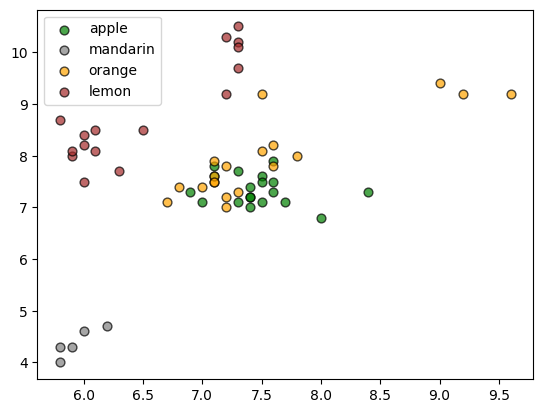

In [42]:
features = ['width', 'height']
X = df_fruits[features].values
y = df_fruits['fruit_label'].values -1  # shift due to labels of fruits are from 1 

df_fruits.head(20)
# labels =  df_fruits['fruit_name'].unique()
fruits_dict = dict(zip(np.unique(y), df_fruits['fruit_name'].unique()))

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 3)
print ('X_train.shape= ',X_train.shape)
print ('X_test.shape= ',X_test.shape)
print ('y_train.shape= ',y_train.shape)
print ('y_test.shape= ',y_test.shape)

print ('target names :', fruits_dict)

plt.figure()
plot_multi_class_logistic_regression (X,y,dict_names=fruits_dict)


train accuracy= 95.455%
test accuracy= 80.000%


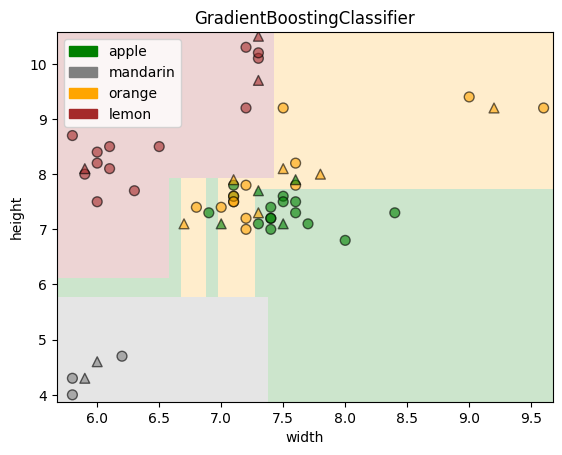

In [43]:
plt.figure ()
labels =list(fruits_dict.values())

clf = GradientBoostingClassifier(learning_rate=0.01,max_depth=3).fit(X_train, y_train)
print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))
plot_decision_boundary_universal(clf, X_train, y_train, X_test, y_test, title='GradientBoostingClassifier', precision=0.05, labels= labels, features = features)


---

<font color = green>

##  XGBoost
</font>



In [44]:
!pip install XGBoost

In [45]:
from xgboost import XGBClassifier

clf_xgboost = XGBClassifier(use_label_encoder=False, eval_metric= 'logloss')
clf_xgboost.fit(X_train, y_train)
print('\nAccuracy of Logistic regression classifier on training set: {:.2f}'
     .format(clf_xgboost.score(X_train, y_train)))
print('Accuracy of Logistic regression classifier on test set: {:.2f}'
     .format(clf_xgboost.score(X_test, y_test)))




Accuracy of Logistic regression classifier on training set: 0.98
Accuracy of Logistic regression classifier on test set: 0.60


/Users/deructu/amazinum/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [10:33:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [46]:
help(XGBClassifier)

Help on class XGBClassifier in module xgboost.sklearn:

class XGBClassifier(sklearn.base.ClassifierMixin, XGBModel)
 |  XGBClassifier(*, objective: Union[str, xgboost.sklearn._SklObjWProto, Callable[[Any, Any], Tuple[numpy.ndarray, numpy.ndarray]], NoneType] = 'binary:logistic', **kwargs: Any) -> None
 |
 |  Implementation of the scikit-learn API for XGBoost classification.
 |  See :doc:`/python/sklearn_estimator` for more information.
 |
 |  Parameters
 |  ----------
 |
 |      n_estimators : Optional[int]
 |          Number of boosting rounds.
 |
 |      max_depth :  typing.Optional[int]
 |
 |          Maximum tree depth for base learners.
 |
 |      max_leaves : typing.Optional[int]
 |
 |          Maximum number of leaves; 0 indicates no limit.
 |
 |      max_bin : typing.Optional[int]
 |
 |          If using histogram-based algorithm, maximum number of bins per feature
 |
 |      grow_policy : typing.Optional[str]
 |
 |          Tree growing policy.
 |
 |          - depthwise: Favo

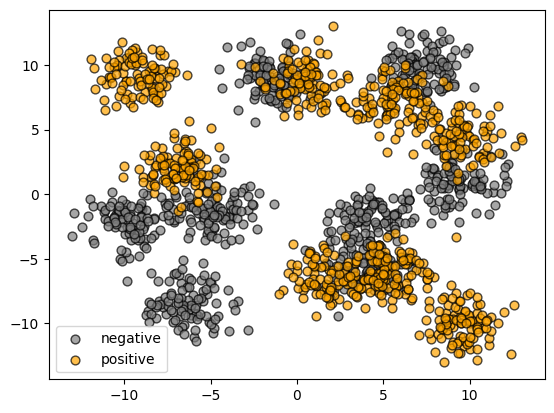

In [47]:
X_mk8, y_mk8 = make_blobs(n_samples = 2000, n_features = 2, centers = 16, # centers impacts for y
                       cluster_std = 1.3, random_state = 4)
X = X_mk8
y = y_mk8 % 2 # make it binary since make_blobs  with centers = 8 creates y in [0..7]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)
plt.figure()
plot_data_logistic_regression(X_train,y_train)

In [48]:
print(X_train.shape)
y_train.shape

(1500, 2)


(1500,)

In [49]:
X_train

array([[ -7.11271763,  -2.18572036],
       [  9.04587707, -11.46625813],
       [ -4.37859762,   1.69193429],
       ...,
       [  5.26290094,  -5.6390031 ],
       [  1.0183784 ,  -6.95986805],
       [ -6.21752906,  -0.20391296]], shape=(1500, 2))

In [50]:
common_max_depth = 3
seed = 10

print('='*30)
print('DECISION TREE')
clf_dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=seed,        
    max_depth=common_max_depth
).fit(X_train, y_train)
print("Train accuracy = {:.3%}".format(clf_dt.score(X_train, y_train)))
print("Test accuracy  = {:.3%}".format(clf_dt.score(X_test, y_test)))

print('\n' + '='*30)
print('RANDOM FOREST')
clf_rf = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    max_depth=common_max_depth,
    random_state=seed
).fit(X_train, y_train)
print("Train accuracy = {:.3%}".format(clf_rf.score(X_train, y_train)))
print("Test accuracy  = {:.3%}".format(clf_rf.score(X_test, y_test)))

print('\n' + '='*30)
print('GRADIENT BOOSTING')
clf_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=common_max_depth,
    random_state=seed
).fit(X_train, y_train)
print("Train accuracy = {:.3%}".format(clf_gb.score(X_train, y_train)))
print("Test accuracy  = {:.3%}".format(clf_gb.score(X_test, y_test)))

print('\n' + '='*30)
print('XGBOOST')
clf_xgb = XGBClassifier(
    use_label_encoder=False, 
    eval_metric='logloss',
    n_estimators=100,
    max_depth=common_max_depth, 
    random_state=seed
).fit(X_train, y_train)
print("Train accuracy = {:.3%}".format(clf_xgb.score(X_train, y_train)))
print("Test accuracy  = {:.3%}".format(clf_xgb.score(X_test, y_test)))

DECISION TREE
Train accuracy = 82.267%
Test accuracy  = 78.400%

RANDOM FOREST
Train accuracy = 85.800%
Test accuracy  = 80.200%

GRADIENT BOOSTING
Train accuracy = 91.667%
Test accuracy  = 83.000%

XGBOOST
Train accuracy = 93.000%
Test accuracy  = 83.400%


/Users/deructu/amazinum/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [10:33:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<font color = green >
    
# Home Task 

</font>



<font color = green>

##  Brest cancer  dataset
</font>



In [51]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X, y, labels, features = cancer.data, cancer.target, cancer.target_names, cancer.feature_names
print ('labels:',labels)
print ('features:', features)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)

labels: ['malignant' 'benign']
features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


<font color = green>

##  DecisionTree 

</font>



#### Searching best params with GridSearch (намагався створити функцію щоб кожен раз не повторювати код але не зміг( )


In [52]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=20)

# Seaching best params saw this in lecture 4
decision_tree_g = GridSearchCV(
    estimator=Pipeline(
        [
            ('scaler', StandardScaler()),
            ('model', DecisionTreeClassifier())
        ]
    ),

    param_grid={
        'model__criterion'     : ['gini', 'entropy'],
        'model__max_depth'     : [2, 3, 4, 5, 5],
        'model__max_leaf_nodes': [2, 3, 4, 5, 5]
    },
    scoring='roc_auc',
    cv=cv,
    refit=True
)
decision_tree_g.fit(X_train, y_train)


decision_tree_results = pd.DataFrame(decision_tree_g.cv_results_)[
    [
        'param_model__criterion',      
        'param_model__max_depth',       
        'param_model__max_leaf_nodes',
        'mean_test_score',
        'rank_test_score'
    ]
]

print(f'Best model parameters: {decision_tree_g.best_params_}\nBest test score: {decision_tree_g.best_score_.round(3)}')


decision_tree_results.sort_values(['mean_test_score', 'param_model__max_depth'], ascending=[False, True]).round(3)



Best model parameters: {'model__criterion': 'entropy', 'model__max_depth': 3, 'model__max_leaf_nodes': 5}
Best test score: 0.949


,param_model__criterion,param_model__max_depth,param_model__max_leaf_nodes,mean_test_score,rank_test_score
34,entropy,3,5,0.949,1
39,entropy,4,5,0.949,1
43,entropy,5,5,0.949,1
48,entropy,5,5,0.949,1
33,entropy,3,5,0.946,5
38,entropy,4,5,0.946,5
44,entropy,5,5,0.946,5
49,entropy,5,5,0.946,5
28,entropy,2,5,0.943,9
29,entropy,2,5,0.943,9


#### Training with best params

train accuracy= 96.009%
test accuracy= 95.804%


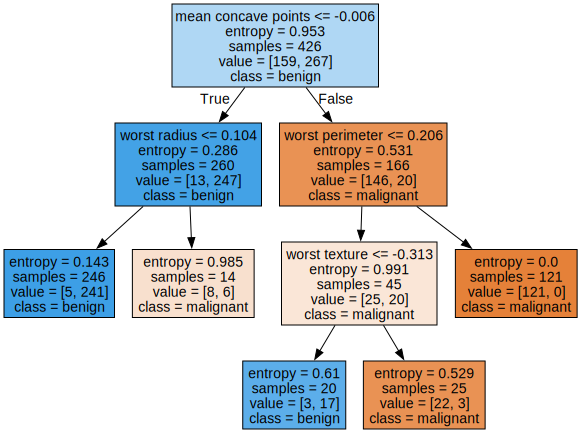

'Source.gv.pdf'

In [53]:
# YOUR_CODE.  create the classifier and train it 
# START_CODE 
clf = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('model', DecisionTreeClassifier(criterion='entropy', max_depth=3, max_leaf_nodes=5))
    ]
)

clf.fit(X_train, y_train)
predict_clf = clf.predict(X_test)
predict_proba_clf = clf.predict_proba(X_test)
# END_CODE 

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))
graph_viz = tree.export_graphviz(clf['model'], out_file=None,feature_names=features, class_names=labels, filled = True) # змінив "clf['model']" щоб дістатись до дерева бо модель в пайплайні 
graph = graphviz.Source(graph_viz)
display(graph) # Додав display бо чомусь view не виводило
graph.view(cleanup=True) # cleanup (bool) – Delete the source file after rendering.

#### Confusion matrix, Precison x Recall, RocCurve

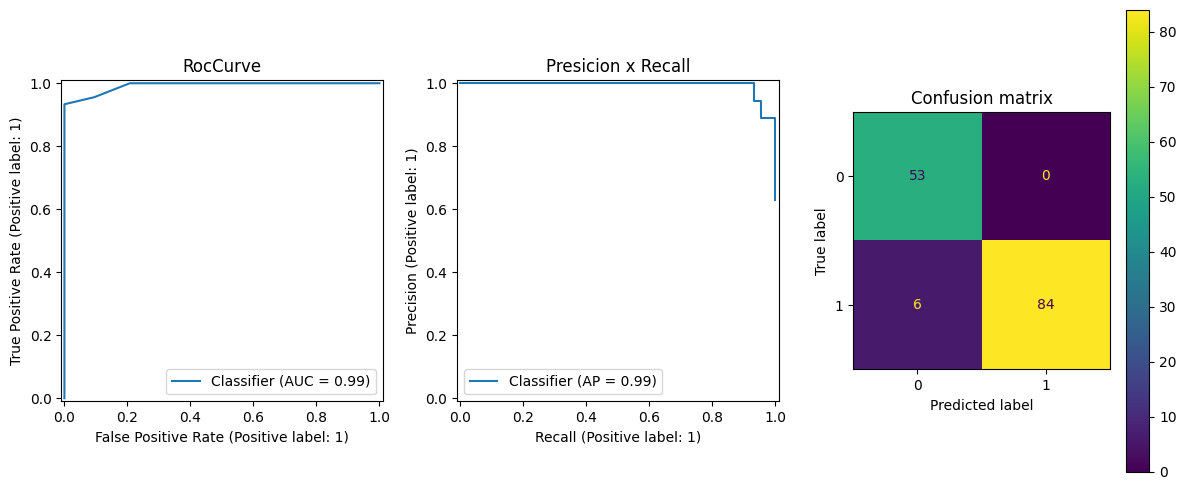

In [54]:
def ploting_metrics(y_test, y_pred, y_pred_proba):
    from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay, PrecisionRecallDisplay

    fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))
    
    RocCurveDisplay.from_predictions(y_test, y_pred_proba[:, 1], ax=axs[0])
    axs[0].set_title('RocCurve')

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axs[2])
    axs[1].set_title('Presicion x Recall')

    PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba[:, 1], ax=axs[1])
    axs[2].set_title('Confusion matrix')

    fig.tight_layout()

ploting_metrics(y_test, predict_clf, predict_proba_clf)



#### Feature importance

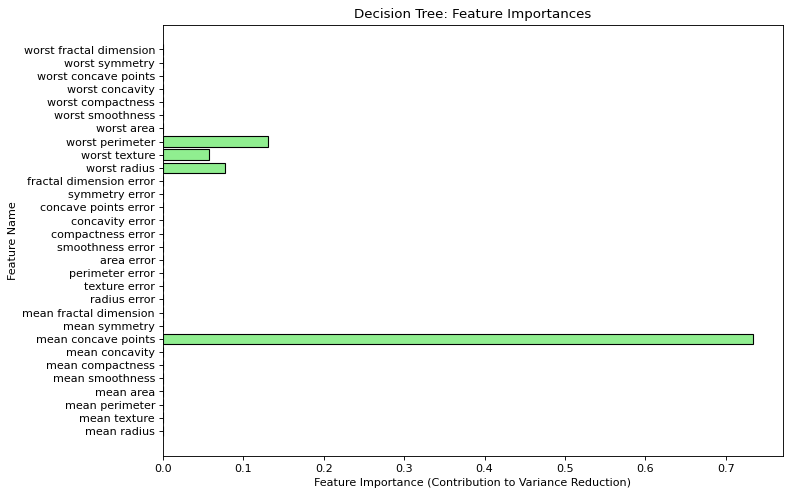

<Figure size 640x480 with 0 Axes>

In [55]:
def plot_feature_importances(clf, features, model_name):
    plt.figure(figsize=(10, 7), dpi=80)
    n_features = len(features)
    plt.barh(range(n_features), clf.feature_importances_, color='lightgreen', edgecolor='black')
    plt.xlabel("Feature Importance (Contribution to Variance Reduction)")
    plt.ylabel("Feature Name")
    plt.yticks(np.arange(n_features), features)
    plt.title(f"{model_name}: Feature Importances")
    plt.show()
    plt.tight_layout()

plot_feature_importances(clf['model'], features, model_name='Decision Tree')

<font color = green>

##  RandomForest

</font>



#### Searching best params with GridSearch


In [56]:
random_forest_g = GridSearchCV(
    estimator=Pipeline(
        [
            ('scaler', StandardScaler()),
            ('model', RandomForestClassifier())
        ]
    ),

    param_grid={
        'model__criterion'     : ['gini', 'entropy'],
        'model__n_estimators'  : [5, 10, 20, 50, 100],
        'model__max_depth'     : [2, 3, 4, 5, 5],
        'model__max_leaf_nodes': [2, 3, 4, 5, 5]
    },
    scoring='roc_auc',
    cv=cv,
    refit=True,
    n_jobs=-1
)
random_forest_g.fit(X_train, y_train)


random_forest_results = pd.DataFrame(random_forest_g.cv_results_)[
    [
        'param_model__criterion',
        'param_model__n_estimators',      
        'param_model__max_depth',       
        'param_model__max_leaf_nodes',
        'mean_test_score',
        'rank_test_score'
    ]
]

print(f'Best model parameters: {random_forest_g.best_params_}\nBest test score: {random_forest_g.best_score_.round(3)}')


random_forest_results.sort_values(['mean_test_score', 'param_model__max_depth'], ascending=[False, True]).round(3)


Best model parameters: {'model__criterion': 'gini', 'model__max_depth': 4, 'model__max_leaf_nodes': 5, 'model__n_estimators': 20}
Best test score: 0.989


,param_model__criterion,param_model__n_estimators,param_model__max_depth,param_model__max_leaf_nodes,mean_test_score,rank_test_score
72,gini,20,4,5,0.989,1
196,entropy,10,4,5,0.988,2
221,entropy,10,5,5,0.988,3
67,gini,20,4,5,0.988,4
124,gini,100,5,5,0.988,5
...,...,...,...,...,...,...
110,gini,5,5,4,0.966,246
165,entropy,5,3,5,0.966,247
125,entropy,5,2,2,0.966,248
225,entropy,5,5,2,0.957,249


#### Studing model with best params

In [57]:
# YOUR_CODE.  create the classifier and train it 
# START_CODE 
clf = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(
            criterion='gini', 
            n_estimators=10, 
            max_depth=3, 
            max_leaf_nodes=5,
        ))
    ]
)

clf.fit(X_train, y_train)

pred_random_forest = clf.predict(X_test)
pred_random_forest_proba = clf.predict_proba(X_test)
# END_CODE 

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 96.479%
test accuracy= 95.804%


#### RocCurve, Precision x Recall, Confusion matrix

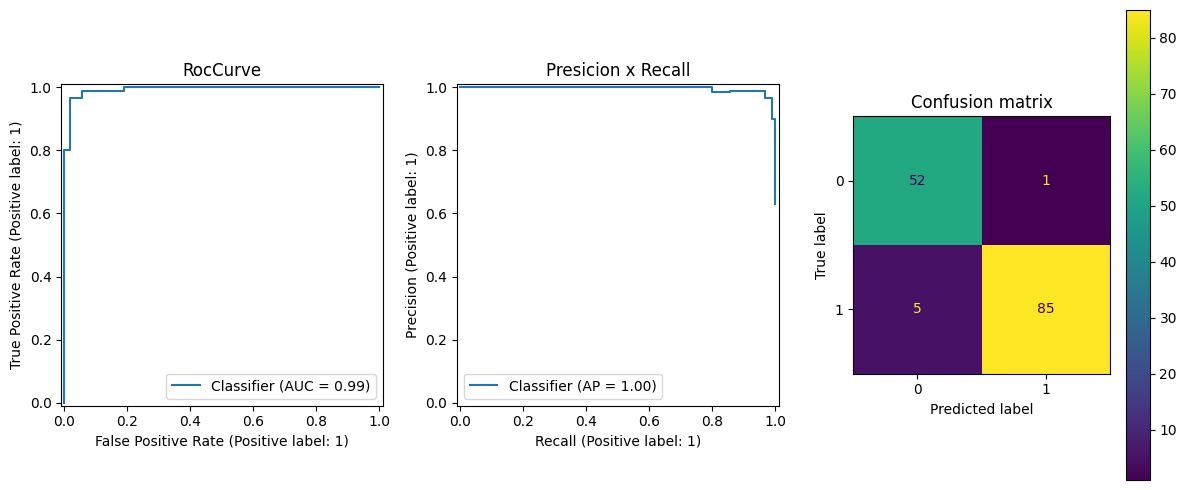

In [58]:
ploting_metrics(y_test, pred_random_forest, pred_random_forest_proba)

#### Feature importance

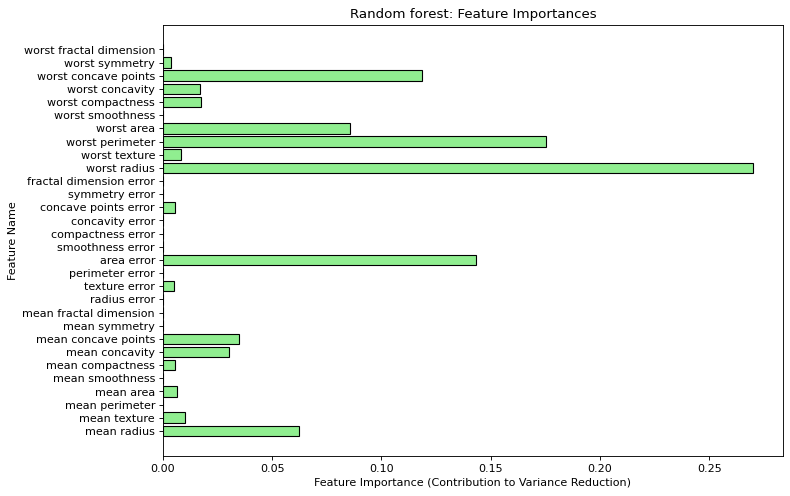

<Figure size 640x480 with 0 Axes>

In [59]:
plot_feature_importances(clf['model'], features, 'Random forest')

<font color = green>

##  Gradient Boosting Decision Trees (GBDT)

</font>



#### Searching best params

In [60]:
gradient_boosting_DT = GridSearchCV(
    estimator=Pipeline(
        [
            ('scaler', StandardScaler()),
            ('model', GradientBoostingClassifier())
        ]
    ),

    param_grid={
        'model__learning_rate' : [0.01, 0.1, 1],
        'model__n_estimators'  : [5, 10, 20, 50, 100],
        'model__max_depth'     : [2, 3, 4, 5, 5],
        'model__max_leaf_nodes': [2, 3, 4, 5, 5]
    },
    scoring='roc_auc',
    cv=cv,
    refit=True,
    n_jobs=-1
)
gradient_boosting_DT.fit(X_train, y_train)


gradient_boosting_DT_results = pd.DataFrame(gradient_boosting_DT.cv_results_)[
    [
        'param_model__learning_rate',
        'param_model__n_estimators',      
        'param_model__max_depth',       
        'param_model__max_leaf_nodes',
        'mean_test_score',
        'rank_test_score'
    ]
]

print(f'Best model parameters: {gradient_boosting_DT.best_params_}\nBest test score: {gradient_boosting_DT.best_score_.round(3)}')


gradient_boosting_DT_results.sort_values(['mean_test_score', 'param_model__max_depth'], ascending=[False, True]).round(3)

Best model parameters: {'model__learning_rate': 1, 'model__max_depth': 2, 'model__max_leaf_nodes': 2, 'model__n_estimators': 100}
Best test score: 0.99


,param_model__learning_rate,param_model__n_estimators,param_model__max_depth,param_model__max_leaf_nodes,mean_test_score,rank_test_score
254,1.00,100,2,2,0.990,1
304,1.00,100,4,2,0.990,1
329,1.00,100,5,2,0.990,1
354,1.00,100,5,2,0.990,1
279,1.00,100,3,2,0.990,5
...,...,...,...,...,...,...
51,0.01,10,4,2,0.921,366
75,0.01,5,5,2,0.921,366
76,0.01,10,5,2,0.921,366
100,0.01,5,5,2,0.921,366


In [61]:
# YOUR_CODE.  create the classifier and train it 
# START_CODE 
clf = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('model', GradientBoostingClassifier(
            learning_rate=1, 
            max_depth=2, 
            max_leaf_nodes=2, 
            n_estimators=100
        ))
    ]
)
clf.fit(X_train, y_train)

pred_GBDT = clf.predict(X_test)
pred_porba_GBDT = clf.predict_proba(X_test)

# END_CODE 

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 97.902%


#### RocCurve, Precision x Recall, Confusion matrix

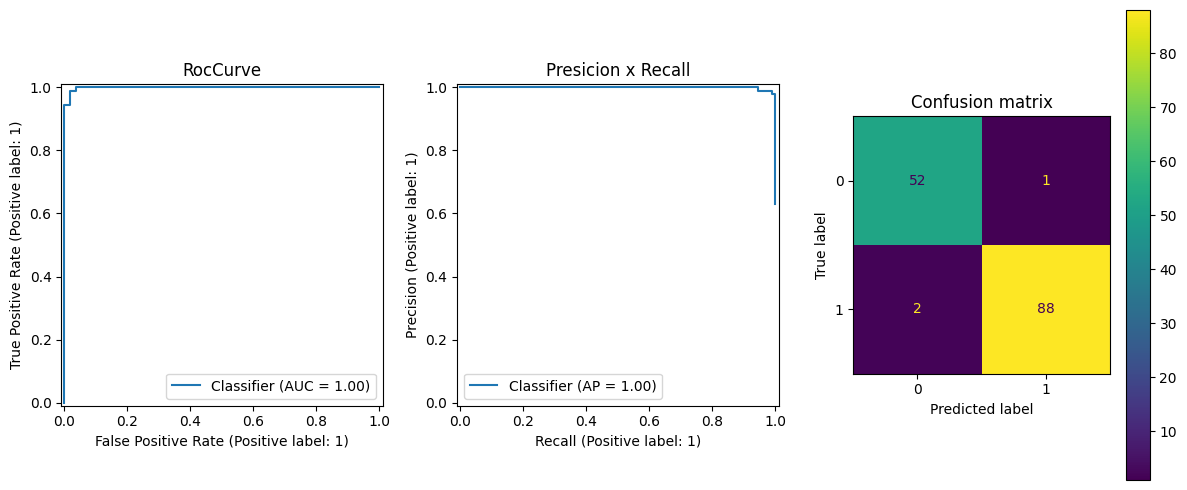

In [62]:
ploting_metrics(y_test, pred_GBDT, pred_porba_GBDT)

#### Feature importance

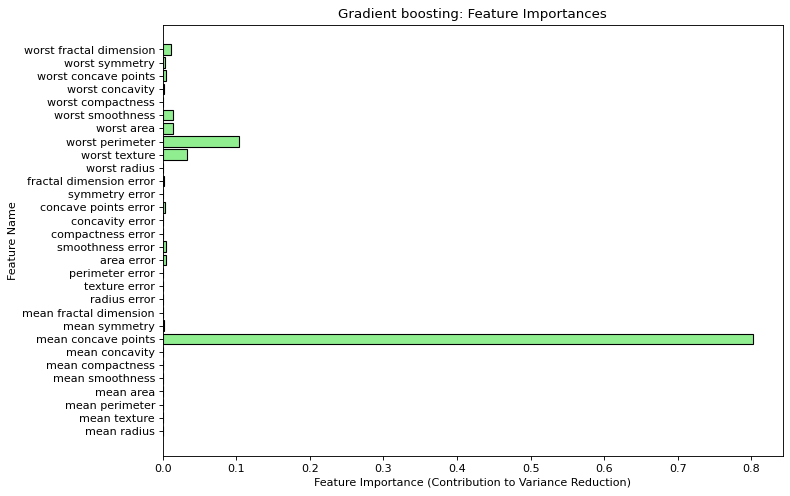

<Figure size 640x480 with 0 Axes>

In [63]:
plot_feature_importances(clf['model'], features, model_name='Gradient boosting')

<font color = green>

##  XGBoost

</font>



#### Searching best params

In [64]:
from xgboost import XGBClassifier
XG_boost = GridSearchCV(
    estimator=Pipeline(
        [
            ('scaler', StandardScaler()),
            ('model', XGBClassifier())
        ]
    ),

    param_grid={
        'model__learning_rate' : [0.01, 0.1, 1],
        'model__n_estimators'  : [5, 10, 20, 50, 100],
        'model__max_depth'     : [2, 3, 4, 5, 5],
        'model__reg_alpha'     : [0.1, 1],
        'model__reg_lambda'    : [0.1, 1]
    },
    scoring='roc_auc',
    cv=cv,
    refit=True,
    n_jobs=-1
)
XG_boost.fit(X_train, y_train)


XG_boost_results = pd.DataFrame(XG_boost.cv_results_)[
    [
        'param_model__learning_rate',
        'param_model__n_estimators',      
        'param_model__max_depth',       
        'param_model__reg_alpha',
        'param_model__reg_lambda', 
        'mean_test_score',
        'rank_test_score'
    ]
]

print(f'Best model parameters: {XG_boost.best_params_}\nBest test score: {XG_boost.best_score_.round(3)}')


XG_boost_results.sort_values(['mean_test_score', 'param_model__max_depth'], ascending=[False, True]).round(3)

Best model parameters: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__reg_alpha': 0.1, 'model__reg_lambda': 0.1}
Best test score: 0.986


,param_model__learning_rate,param_model__n_estimators,param_model__max_depth,param_model__reg_alpha,param_model__reg_lambda,mean_test_score,rank_test_score
116,0.10,100,2,0.1,0.1,0.986,1
244,1.00,10,4,0.1,0.1,0.986,2
118,0.10,100,2,1.0,0.1,0.986,3
117,0.10,100,2,0.1,1.0,0.985,4
119,0.10,100,2,1.0,1.0,0.985,5
...,...,...,...,...,...,...,...
5,0.01,10,2,0.1,1.0,0.935,296
0,0.01,5,2,0.1,0.1,0.935,297
1,0.01,5,2,0.1,1.0,0.932,298
3,0.01,5,2,1.0,1.0,0.932,298


In [65]:
# YOUR_CODE.  create the classifier and train it 
# START_CODE 
clf = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('model', XGBClassifier(
            learning_rate=0.1,
            n_estimators=100,
            max_depth=2,
            reg_alpha=0.1,
            reg_lambda=0.1
        ))
    ]
)

clf.fit(X_train, y_train)

pred_XG_boost = clf.predict(X_test)
pred_proba_XG_boost = clf.predict_proba(X_test)
# END_CODE 

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 97.902%


#### Visualisation metrics

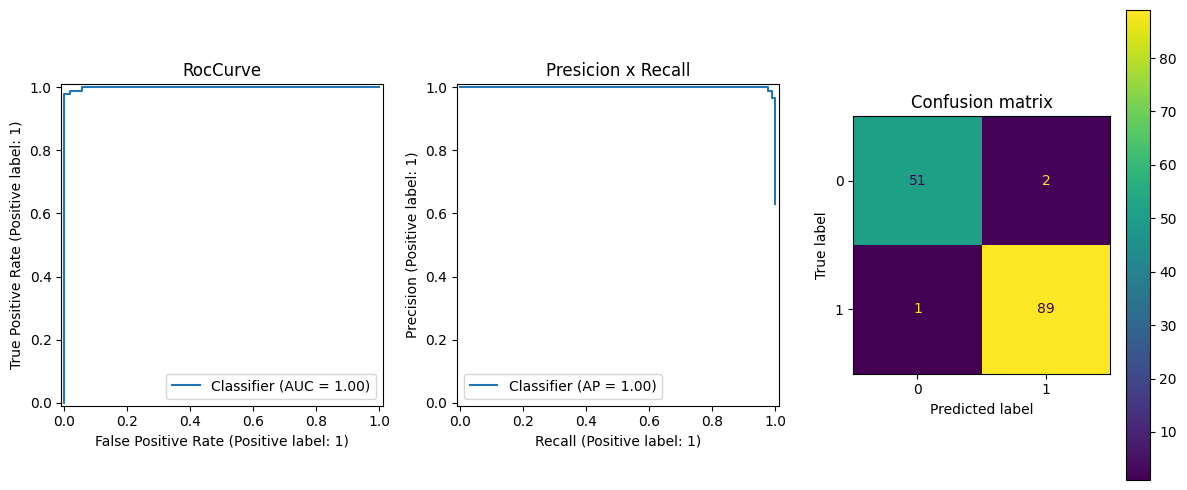

In [66]:
ploting_metrics(y_test, pred_XG_boost, pred_proba_XG_boost)

#### Feature importance

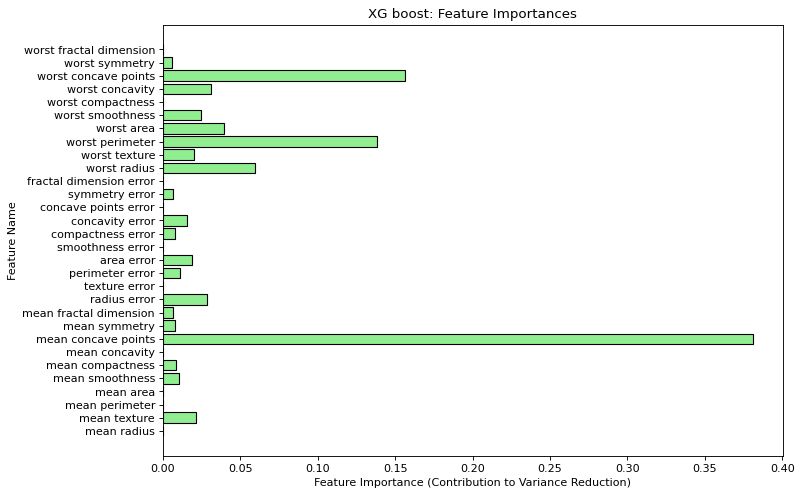

<Figure size 640x480 with 0 Axes>

In [67]:
plot_feature_importances(clf['model'], features, model_name='XG boost')

# Additional tasks

### 1) Binary Classification:
    Task: Train an XGBClassifier to predict whether a person's income exceeds $50,000 per year based on census data (age, education, occupation, etc.).

### 2) Regression:
    Task: Train an XGBRegressor to predict the final sale price of houses in Ames, Iowa, based on various features (area, quality, year built).

_____________________________________________________________________________________________________________________________________________________________________________________________________________________

## Assessment Criteria and Requirements

I will evaluate the entire process of working on your project—from the moment you load the dataset to the final result. Your task is to apply all the knowledge you have gained in lectures up to this point.

There is no minimum accuracy threshold: the main focus will be on the quality of implementation. However, if the model’s accuracy is too low, the assignment may not be accepted.

In [68]:
from sklearn.datasets import fetch_openml
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Classification:

In [87]:
data_class = fetch_openml(name='adult', version=2, as_frame=True)
df_income = data_class.frame
df_income

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


## Preprocesing

#### Info about dataset 

In [88]:
df_income.info() # in workclass occupation and native country can see missining value

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


#### Info about numeric data

In [89]:
df_income.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


#### Missining values in persentage and drop this values

In [91]:
print(f'Missining values in percentage:\n\n{(df_income.isna().sum() / len(df_income)) * 100}')

df_income.dropna(inplace=True)

Missining values in percentage:

age               0.0
workclass         0.0
fnlwgt            0.0
education         0.0
education-num     0.0
marital-status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital-gain      0.0
capital-loss      0.0
hours-per-week    0.0
native-country    0.0
class             0.0
dtype: float64


#### Count of classes

<Axes: xlabel='class', ylabel='count'>

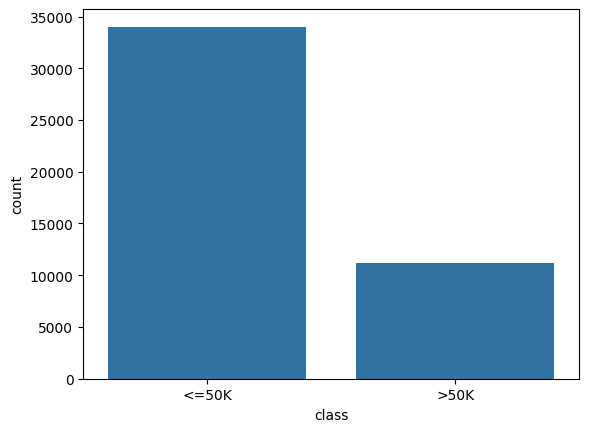

In [92]:
sns.countplot(data=df_income, x='class') # see disbalance

## Classificator model

#### Spliting data and encoding category columns

In [93]:
X = df_income.drop('class', axis=1)
y = df_income['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

X_train_cat = X_train.copy()
X_test_cat = X_test.copy()


encoders = {}
for col in X_train.select_dtypes(include=['category']).columns:
    le = LabelEncoder() # new encoder for new column
    X_train_cat[col] = le.fit_transform(X_train_cat[col])
    X_test_cat[col] = le.transform(X_test_cat[col])
    encoders[col] = dict(zip(le.classes_, range(len(le.classes_))))

y_le = LabelEncoder()
y_train_cat = y_le.fit_transform(y_train)
y_test_cat = y_le.transform(y_test)

print('y:', dict(zip(y_le.classes_, y_le.transform(y_le.classes_))))
print('X_train_cat.shape=', X_train_cat.shape)
print('y_train_cat.shape=', y_train_cat.shape)
X_train_cat

y: {'<=50K': np.int64(0), '>50K': np.int64(1)}
X_train_cat.shape= (33916, 14)
y_train_cat.shape= (33916,)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
39329,18,2,298860,1,7,4,11,3,4,1,0,0,20,38
1172,44,4,188278,7,12,0,3,4,2,0,0,0,45,38
19435,41,2,119079,11,9,2,11,0,4,1,0,0,49,38
14704,50,4,343242,15,10,2,13,0,4,1,0,0,55,38
46563,34,2,28053,9,13,3,0,1,4,0,0,0,25,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32850,64,1,84737,11,9,2,7,0,1,1,0,0,35,38
22994,48,2,205424,9,13,0,11,4,4,1,0,0,40,38
46012,21,2,132053,15,10,4,0,3,4,0,0,1721,35,38
47046,38,2,252897,15,10,0,11,3,4,0,0,0,25,38


#### Searching best params with GridSearch

In [75]:
from xgboost import XGBClassifier
XG_boost = GridSearchCV(
    estimator=Pipeline(
        [
            ('scaler', StandardScaler()),
            ('model', XGBClassifier())
        ]
    ),

    param_grid={
        'model__learning_rate' : [0.01, 0.1, 1],
        'model__n_estimators'  : [50, 100, 200],
        'model__max_depth'     : [4, 6, 10],
        'model__reg_alpha'     : [0.1, 0.5, 1],
        'model__reg_lambda'    : [0.1, 0.5, 1]
    },
    scoring='roc_auc',
    cv=cv,
    refit=True,
    n_jobs=-1
)
XG_boost.fit(X_train_cat, y_train_cat)


XG_boost_results = pd.DataFrame(XG_boost.cv_results_)[
    [
        'param_model__learning_rate',
        'param_model__n_estimators',      
        'param_model__max_depth',       
        'param_model__reg_alpha',
        'param_model__reg_lambda', 
        'mean_test_score',
        'rank_test_score'
    ]
]

print(f'Best model parameters: {XG_boost.best_params_}\nBest test score: {XG_boost.best_score_.round(3)}')


XG_boost_results.sort_values(['mean_test_score', 'param_model__max_depth'], ascending=[False, True]).round(3)

Best model parameters: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 200, 'model__reg_alpha': 0.1, 'model__reg_lambda': 0.1}
Best test score: 0.929


,param_model__learning_rate,param_model__n_estimators,param_model__max_depth,param_model__reg_alpha,param_model__reg_lambda,mean_test_score,rank_test_score
99,0.10,200,4,0.1,0.1,0.929,1
128,0.10,200,6,0.1,1.0,0.928,2
131,0.10,200,6,0.5,1.0,0.928,3
130,0.10,200,6,0.5,0.5,0.928,4
102,0.10,200,4,0.5,0.1,0.928,5
...,...,...,...,...,...,...,...
1,0.01,50,4,0.1,0.5,0.888,239
5,0.01,50,4,0.5,1.0,0.888,240
7,0.01,50,4,1.0,0.5,0.888,241
6,0.01,50,4,1.0,0.1,0.888,242


#### Train and predicting model with best params

In [94]:
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, roc_auc_score
XG_boost_model = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('model', XGBClassifier(
            learning_rate=0.1,
            n_estimators=200,
            max_depth=4,
            reg_alpha=0.1,
            reg_lambda=1.0
        ))
    ]
)

XG_boost_model.fit(X_train_cat, y_train_cat)

pred_XG_boost_model = XG_boost_model.predict(X_test_cat)
pred_XG_boost_model_proba = XG_boost_model.predict_proba(X_test_cat)

# metrics
print(f'Accuracy score: {accuracy_score(y_test_cat, pred_XG_boost_model)}')
print(f'Precision score: {precision_score(y_test_cat, pred_XG_boost_model)}')
print(f'Recall score: {recall_score(y_test_cat, pred_XG_boost_model)}')
print(f'F1-score: {f1_score(y_test_cat, pred_XG_boost_model)}')
print(f'Roc-Auc score: {roc_auc_score(y_test_cat, pred_XG_boost_model_proba[:, 1])} ')


Accuracy score: 0.8640544843445958
Precision score: 0.7818181818181819
Recall score: 0.6361394857344135
F1-score: 0.7014954360069916
Roc-Auc score: 0.9230854113059288 


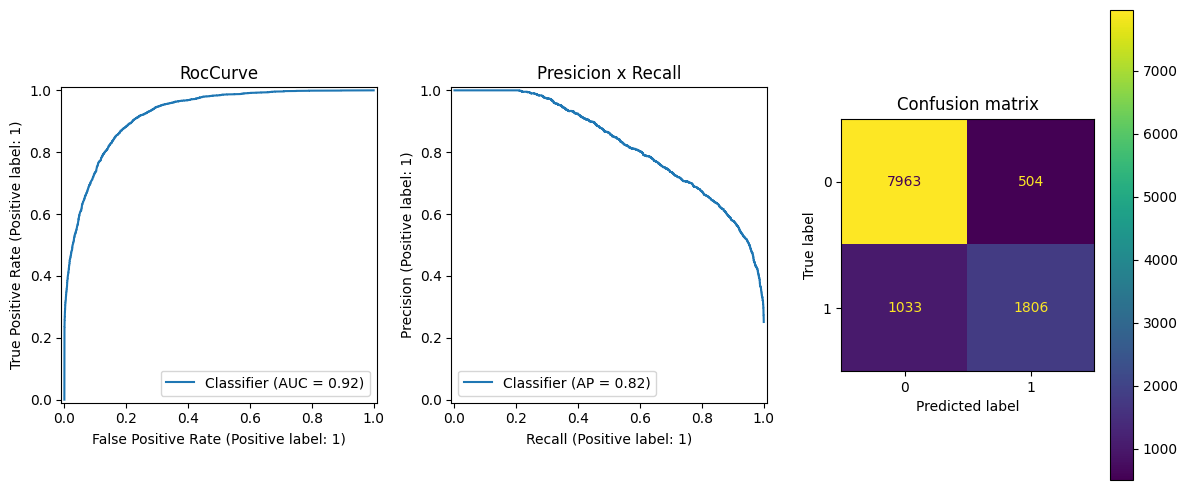

In [77]:
ploting_metrics(y_test_cat, pred_XG_boost_model, pred_XG_boost_model_proba)

#### Future Importance

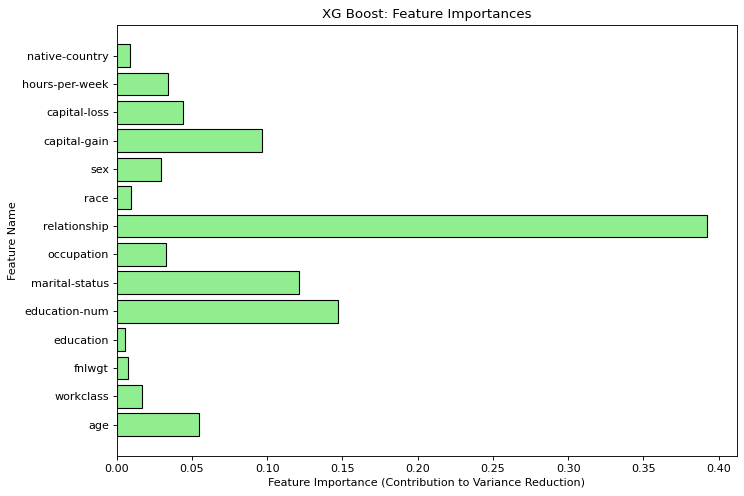

<Figure size 640x480 with 0 Axes>

In [102]:
plot_feature_importances(XG_boost_model['model'], X_train_cat.columns, model_name='XG Boost')

# Regression:

In [78]:
data_reg = fetch_openml(name='house_prices', version=1, as_frame=True)
df_house = data_reg.frame
df_house

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


#### Preprocessing

In [ ]:
df_house.info() # droppong this columns: PoolQC Fence MiscFeature, Fireplaces, Alley, very many missing values

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [120]:
df_cleanded = (df_house
            .drop(['PoolQC', 'Fence', 'MiscFeature', 'Fireplaces', 'Alley', 'FireplaceQu', 'Id'], axis=1)
            .dropna()
)

In [121]:
df_cleanded.info()

<class 'pandas.DataFrame'>
Index: 1094 entries, 0 to 1459
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1094 non-null   int64  
 1   MSZoning       1094 non-null   str    
 2   LotFrontage    1094 non-null   float64
 3   LotArea        1094 non-null   int64  
 4   Street         1094 non-null   str    
 5   LotShape       1094 non-null   str    
 6   LandContour    1094 non-null   str    
 7   Utilities      1094 non-null   str    
 8   LotConfig      1094 non-null   str    
 9   LandSlope      1094 non-null   str    
 10  Neighborhood   1094 non-null   str    
 11  Condition1     1094 non-null   str    
 12  Condition2     1094 non-null   str    
 13  BldgType       1094 non-null   str    
 14  HouseStyle     1094 non-null   str    
 15  OverallQual    1094 non-null   int64  
 16  OverallCond    1094 non-null   int64  
 17  YearBuilt      1094 non-null   int64  
 18  YearRemodAdd   1094 non-

#### Spliting and encoding

In [ ]:
X = df_cleanded.drop('SalePrice', axis=1)
y = df_cleanded['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=10)

#### Searching best params with GridSearch

In [155]:
from xgboost import XGBRegressor

cat_cols = X_train.select_dtypes(include=['str']).columns
cat_cols_test = X_test.select_dtypes(include=['str']).columns
X_train[cat_cols] = X_train[cat_cols].astype('category') # Переводимо в category, бо в XGBOOST є класний аргумент enable_categorical
X_test[cat_cols_test] = X_test[cat_cols_test].astype('category')

XGboost_regresor = GridSearchCV(
    estimator=Pipeline(
        [
            ('model', XGBRegressor(enable_categorical=True)) # заюзав це, бо label encoder кидав помилку
        ]
    ),

    param_grid={
        'model__learning_rate' : [0.01, 0.1, 1],
        'model__n_estimators'  : [50, 100, 200],
        'model__max_depth'     : [2, 4, 8],
        'model__reg_alpha'     : [0.1, 0.5, 1],
        'model__reg_lambda'    : [0.1, 0.5, 1]
    },
    scoring='r2',
    refit=True,
    n_jobs=-1
)
XGboost_regresor.fit(X_train, y_train)


XG_boost_results = pd.DataFrame(XGboost_regresor.cv_results_)[
    [
        'param_model__learning_rate',
        'param_model__n_estimators',      
        'param_model__max_depth',       
        'param_model__reg_alpha',
        'param_model__reg_lambda', 
        'mean_test_score',
        'rank_test_score'
    ]
]

print(f'Best model parameters: {XGboost_regresor.best_params_}\nBest test score: {XGboost_regresor.best_score_.round(3)}')


XG_boost_results.sort_values(['mean_test_score', 'param_model__max_depth'], ascending=[False, True]).round(3)

/Users/deructu/amazinum/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best model parameters: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 200, 'model__reg_alpha': 1, 'model__reg_lambda': 0.1}
Best test score: 0.865


,param_model__learning_rate,param_model__n_estimators,param_model__max_depth,param_model__reg_alpha,param_model__reg_lambda,mean_test_score,rank_test_score
105,0.10,200,2,1.0,0.1,0.865,1
102,0.10,200,2,0.5,0.1,0.865,2
99,0.10,200,2,0.1,0.1,0.865,3
96,0.10,100,2,1.0,0.1,0.864,4
90,0.10,100,2,0.1,0.1,0.864,5
...,...,...,...,...,...,...,...
4,0.01,50,2,0.5,0.5,0.409,239
7,0.01,50,2,1.0,0.5,0.409,240
0,0.01,50,2,0.1,0.1,0.407,241
3,0.01,50,2,0.5,0.1,0.407,242


#### Studing model with best params
 

In [ ]:
XG_boost_regresor = Pipeline(
    [
        ('model', XGBRegressor(
            learning_rate=0.1,
            n_estimators=200,
            max_depth=2,
            reg_alpha=1.0,
            reg_lambda=0.1,
            enable_categorical=True
        ))
    ]
)
XG_boost_regresor.fit(X_train, y_train)
y_pred_XG_boost_regresor = XG_boost_regresor.predict(X_test)

#### Metrics

In [160]:
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error, 
    mean_squared_error,
    r2_score
)

print(f'RMSE: {root_mean_squared_error(y_test, y_pred_XG_boost_regresor)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred_XG_boost_regresor)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_XG_boost_regresor)}')
print(f'R2-score: {r2_score(y_test, y_pred_XG_boost_regresor)}')

RMSE: 32300.708984375
MAE: 17050.5859375
MSE: 1043335744.0
R2-score: 0.8379924893379211


#### Disribution of residual

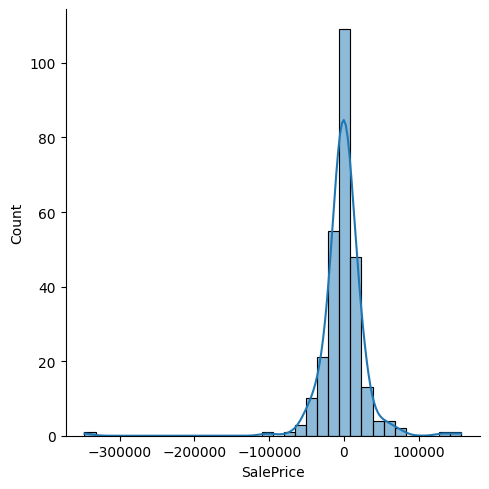

In [ ]:
residual = y_test - y_pred_XG_boost_regresor

sns.displot(residual, kde=True) # є викиди в даних чесно не знаю чи проблема в encoder в модельці чи то викид в датасеті

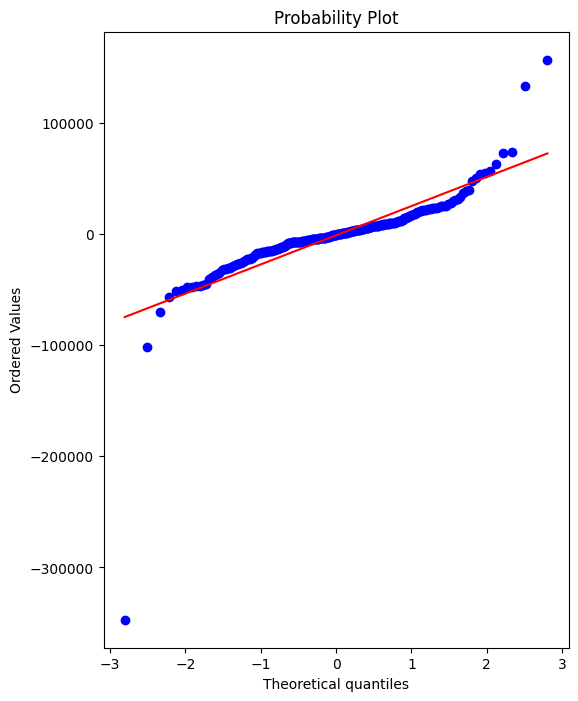

In [ ]:
import scipy as sp

fig, ax = plt.subplots(figsize=(6, 8), dpi=100)

_ = sp.stats.probplot(residual, plot=ax) # впринципі вивід нормальний але бачимо точкий далеко від діагоналі а це викиди в даних